In [15]:
# Phase 1 setup: raw-data-first EDA
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Project paths
METADATA_PATH = Path('metadata.csv')
RECORDS_PATH = Path('RECORDS')
DATA_DIR = Path('files')
FLAGGED_OUTPUT_PATH = Path('data_preprocessing/flagged_recordings_phase1.csv')

# Label mapping for binary analysis
NORMAL_LABEL = 0
BRUGADA_LABEL = 1

# Load metadata and records
metadata = pd.read_csv(METADATA_PATH)
records_raw = [line.strip() for line in RECORDS_PATH.read_text().splitlines() if line.strip()]
records_ids = [Path(r).parts[1] for r in records_raw]

print(f"Metadata rows: {len(metadata)}")
print(f"RECORDS entries: {len(records_ids)}")
print(f"Metadata columns: {list(metadata.columns)}")

Metadata rows: 363
RECORDS entries: 364
Metadata columns: ['patient_id', 'basal_pattern', 'sudden_death', 'brugada']


In [10]:
# 1.1 Data Integrity Checks
required_columns = ['patient_id', 'basal_pattern', 'sudden_death', 'brugada']
missing_required_cols = [c for c in required_columns if c not in metadata.columns]

# Duplicate checks
metadata_id_counts = metadata['patient_id'].value_counts()
duplicate_ids = metadata_id_counts[metadata_id_counts > 1].index.tolist()
unique_patient_count = metadata['patient_id'].nunique()
records_series = pd.Series(records_ids, dtype='string')
duplicate_records_entries = records_series[records_series.duplicated()].dropna().unique().tolist()

# Missing-value checks
missing_summary = metadata.isna().sum().sort_values(ascending=False)
total_missing = int(missing_summary.sum())

# One-to-one mapping between metadata and RECORDS
metadata_ids = set(metadata['patient_id'].astype(str))
records_ids_set = set(records_ids)
ids_only_in_metadata = sorted(metadata_ids - records_ids_set)
ids_only_in_records = sorted(records_ids_set - metadata_ids)

# File existence and shape validation
shape_issues = []
missing_file_issues = []
signal_store = {}
lead_names = None

for pid in metadata['patient_id'].astype(str):
    record_base = DATA_DIR / pid / pid
    dat_path = record_base.with_suffix('.dat')
    hea_path = record_base.with_suffix('.hea')

    if not dat_path.exists() or not hea_path.exists():
        missing_file_issues.append({
            'patient_id': pid,
            'dat_exists': dat_path.exists(),
            'hea_exists': hea_path.exists()
        })
        continue

    record = wfdb.rdrecord(str(record_base))
    signal = record.p_signal
    signal_store[pid] = signal

    if lead_names is None:
        lead_names = list(record.sig_name)

    if signal.shape != (1200, 12):
        shape_issues.append({
            'patient_id': pid,
            'shape_observed': tuple(signal.shape)
        })

integrity_summary = pd.DataFrame({
    'check': [
        'Missing required columns',
        'Unique patient_id count',
        'Duplicate patient_id rows',
        'Duplicate RECORDS entries',
        'Total missing metadata values',
        'IDs only in metadata',
        'IDs only in RECORDS',
        'Missing dat/hea pairs',
        'Signal shape issues (not 1200x12)'
    ],
    'value': [
        len(missing_required_cols),
        unique_patient_count,
        len(duplicate_ids),
        len(duplicate_records_entries),
        total_missing,
        len(ids_only_in_metadata),
        len(ids_only_in_records),
        len(missing_file_issues),
        len(shape_issues)
    ]
})

print('Data Integrity Summary')
display(integrity_summary)

if missing_required_cols:
    print('Missing required columns:', missing_required_cols)
if duplicate_ids:
    print('Duplicate patient_ids:', duplicate_ids[:10])
if duplicate_records_entries:
    print('Duplicate RECORDS entries (first 10):', duplicate_records_entries[:10])
if ids_only_in_metadata:
    print('IDs only in metadata (first 10):', ids_only_in_metadata[:10])
if ids_only_in_records:
    print('IDs only in RECORDS (first 10):', ids_only_in_records[:10])
if shape_issues:
    print('Shape issues (first 5):', shape_issues[:5])

print(f"Loaded raw signals for SQA/EDA: {len(signal_store)} recordings")
print(f"Lead names: {lead_names}")

Data Integrity Summary


,check,value
0,Missing required columns,0
1,Unique patient_id count,363
2,Duplicate patient_id rows,0
3,Duplicate RECORDS entries,1
4,Total missing metadata values,0
5,IDs only in metadata,0
6,IDs only in RECORDS,0
7,Missing dat/hea pairs,0
8,Signal shape issues (not 1200x12),0


Duplicate RECORDS entries (first 10): ['596382']
Loaded raw signals for SQA/EDA: 363 recordings
Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [11]:
# 1.2 Signal Quality Assessment (flatline, amplitude, simple noise ratio)
flatline_eps = 1e-12
amplitude_limit_mv = 5.0
noise_ratio_threshold = 1.0  # simple heuristic based on first-difference energy

flag_rows = []

for pid in metadata['patient_id'].astype(str):
    signal = signal_store.get(pid)
    if signal is None:
        continue

    # Flatline detection per lead
    lead_var = np.var(signal, axis=0)
    flatline_leads = np.where(lead_var <= flatline_eps)[0]
    for li in flatline_leads:
        flag_rows.append({
            'patient_id': pid,
            'lead': lead_names[li],
            'flag_type': 'flatline',
            'metric_value': float(lead_var[li]),
            'threshold': flatline_eps
        })

    # Amplitude threshold check per lead
    lead_abs_max = np.max(np.abs(signal), axis=0)
    amp_flag_leads = np.where(lead_abs_max > amplitude_limit_mv)[0]
    for li in amp_flag_leads:
        flag_rows.append({
            'patient_id': pid,
            'lead': lead_names[li],
            'flag_type': 'amplitude_exceeds_5mV',
            'metric_value': float(lead_abs_max[li]),
            'threshold': amplitude_limit_mv
        })

    # Simple high-frequency noise check per lead
    diff_sig = np.diff(signal, axis=0)
    hf_power = np.var(diff_sig, axis=0)
    signal_power = np.var(signal, axis=0) + 1e-12
    noise_ratio = hf_power / signal_power
    noisy_leads = np.where(noise_ratio > noise_ratio_threshold)[0]
    for li in noisy_leads:
        flag_rows.append({
            'patient_id': pid,
            'lead': lead_names[li],
            'flag_type': 'high_frequency_noise',
            'metric_value': float(noise_ratio[li]),
            'threshold': noise_ratio_threshold
        })

flags_df = pd.DataFrame(flag_rows)
if flags_df.empty:
    flags_df = pd.DataFrame(columns=['patient_id', 'lead', 'flag_type', 'metric_value', 'threshold'])

flags_df.to_csv(FLAGGED_OUTPUT_PATH, index=False)

recording_level_flags = flags_df.groupby('patient_id').size().reset_index(name='num_flags') if not flags_df.empty else pd.DataFrame(columns=['patient_id', 'num_flags'])

print(f"Total flagged lead-events: {len(flags_df)}")
print(f"Total recordings with >=1 flag: {recording_level_flags['patient_id'].nunique() if not recording_level_flags.empty else 0}")
print(f"Saved flagged recordings list to: {FLAGGED_OUTPUT_PATH}")
display(flags_df.head(15))

Total flagged lead-events: 26
Total recordings with >=1 flag: 14
Saved flagged recordings list to: data_preprocessing/flagged_recordings_phase1.csv


,patient_id,lead,flag_type,metric_value,threshold
0,267630,I,high_frequency_noise,1.016427,1.0
1,287355,aVL,high_frequency_noise,1.046784,1.0
2,519139,III,high_frequency_noise,1.304268,1.0
3,801261,V2,high_frequency_noise,1.004578,1.0
4,801261,V5,high_frequency_noise,1.008530,1.0
5,930107,III,high_frequency_noise,1.244367,1.0
6,999474,aVL,high_frequency_noise,1.067337,1.0
7,1088175,aVL,high_frequency_noise,1.222101,1.0
8,1141322,III,high_frequency_noise,1.290302,1.0
9,1141322,aVF,high_frequency_noise,1.029636,1.0


Per-lead descriptive statistics:


,lead,mean,median,min,max,std
0,I,-0.0087,-0.029,-3.071,1.472,0.1103
1,II,0.0009,-0.030,-2.567,3.311,0.2220
2,III,0.0028,-0.009,-2.788,3.424,0.1789
3,aVR,-0.0057,0.020,-1.648,2.346,0.1509
4,aVL,-0.0106,-0.012,-2.969,1.537,0.0989
5,aVF,0.0021,-0.019,-2.632,3.383,0.1956
6,V1,-0.0057,0.005,-3.289,3.188,0.1686
7,V2,-0.0085,-0.028,-3.343,3.360,0.2614
8,V3,-0.0089,-0.052,-2.838,2.822,0.2848
9,V4,-0.0023,-0.057,-2.385,3.331,0.2944


Metadata data types and missing counts:


,column,dtype,missing_values
0,patient_id,int64,0
1,basal_pattern,int64,0
2,sudden_death,int64,0
3,brugada,int64,0


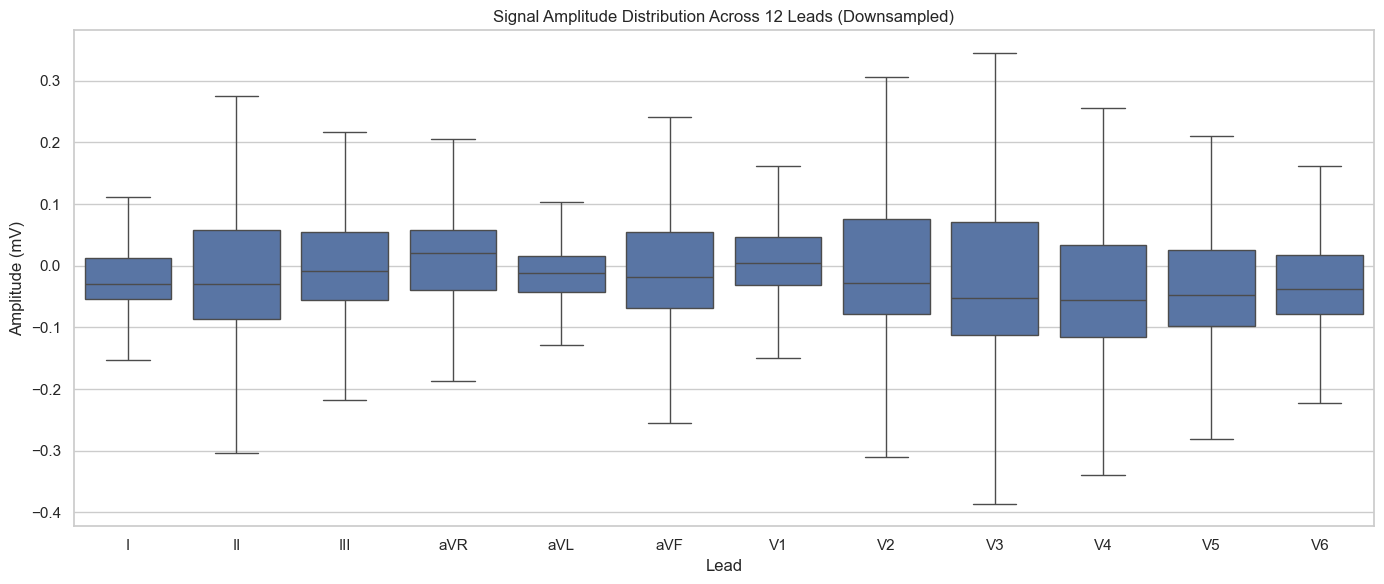

In [12]:
# 1.3 Descriptive Statistics + dtypes and amplitude distributions
valid_pids = [pid for pid in metadata['patient_id'].astype(str) if pid in signal_store]
all_signals = np.stack([signal_store[pid] for pid in valid_pids], axis=0)  # (N, 1200, 12)

lead_mean = np.mean(all_signals, axis=(0, 1))
lead_median = np.median(all_signals, axis=(0, 1))
lead_min = np.min(all_signals, axis=(0, 1))
lead_max = np.max(all_signals, axis=(0, 1))
lead_std = np.std(all_signals, axis=(0, 1))

descriptive_stats = pd.DataFrame({
    'lead': lead_names,
    'mean': lead_mean,
    'median': lead_median,
    'min': lead_min,
    'max': lead_max,
    'std': lead_std
})

print('Per-lead descriptive statistics:')
display(descriptive_stats.round(4))

dtype_table = pd.DataFrame({
    'column': metadata.columns,
    'dtype': [str(metadata[c].dtype) for c in metadata.columns],
    'missing_values': [int(metadata[c].isna().sum()) for c in metadata.columns]
})
print('Metadata data types and missing counts:')
display(dtype_table)

# Box plots across all leads (downsampled for readable plotting)
plot_stride = 10
sampled = all_signals[:, ::plot_stride, :].reshape(-1, all_signals.shape[-1])
box_df = pd.DataFrame(sampled, columns=lead_names).melt(var_name='lead', value_name='amplitude_mV')

plt.figure(figsize=(14, 6))
sns.boxplot(data=box_df, x='lead', y='amplitude_mV', showfliers=False)
plt.title('Signal Amplitude Distribution Across 12 Leads (Downsampled)')
plt.xlabel('Lead')
plt.ylabel('Amplitude (mV)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

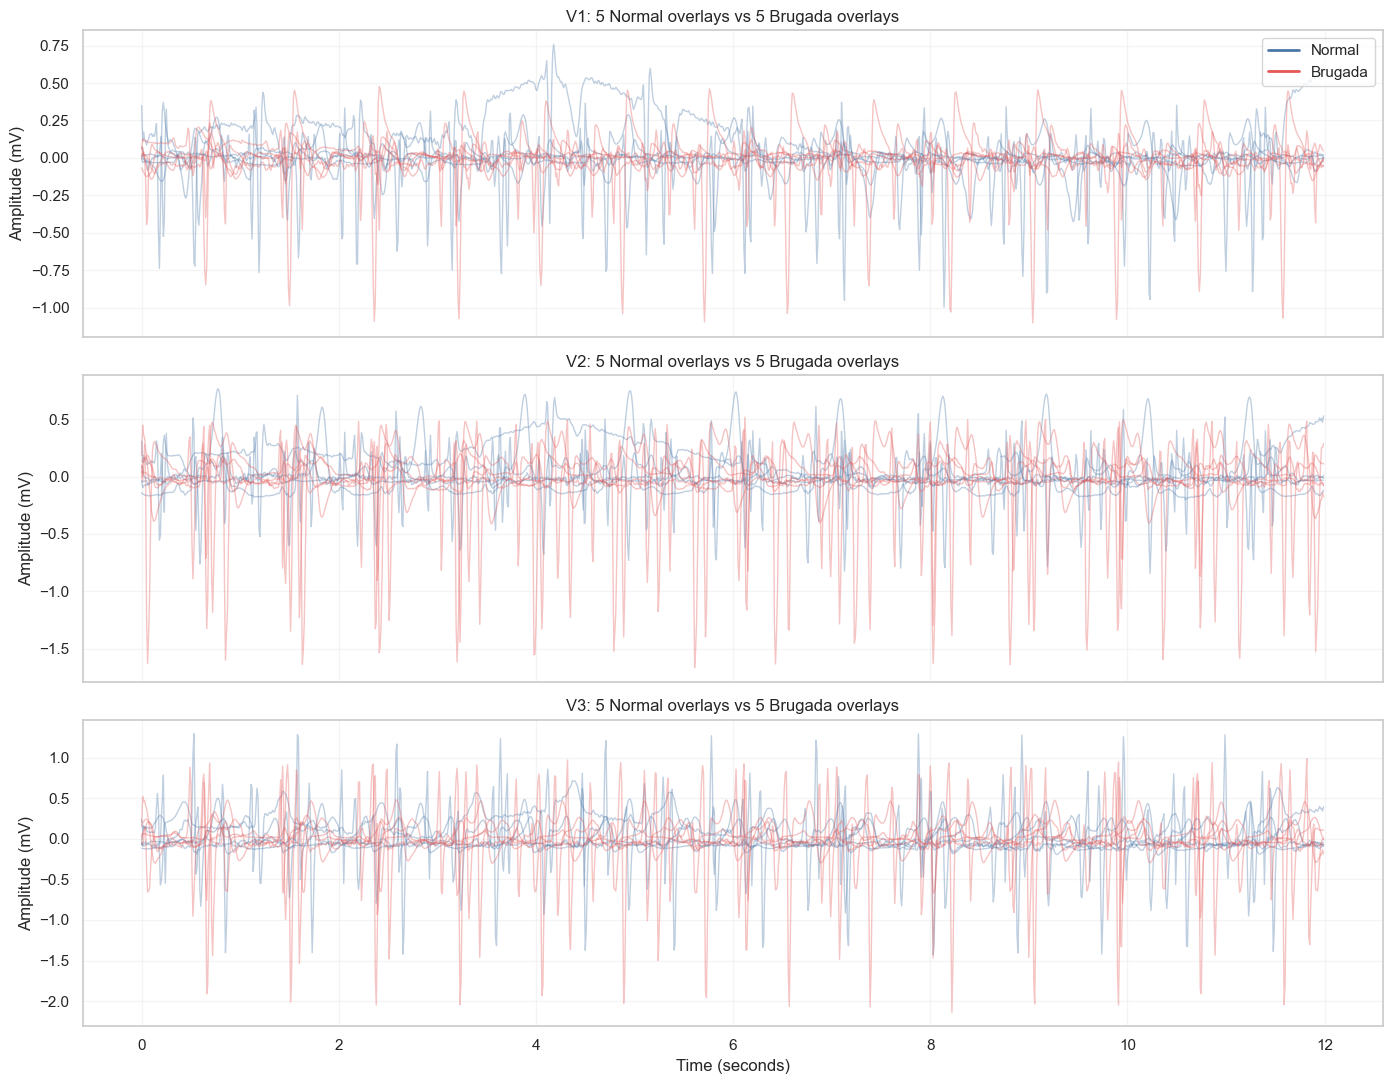

Visual sanity-check note: inspect whether Brugada traces in V1-V3 show coved ST-segment elevation patterns.


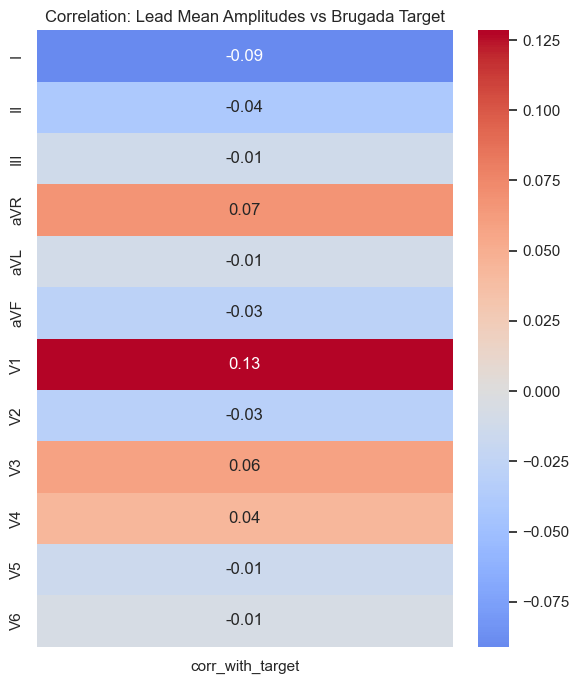

Correlation caveat: correlation does not imply causation; this section is exploratory only.


In [14]:
# 1.5 Lead-Level Visual Inspection + 1.6 Correlation Analysis
lead_to_idx = {name: i for i, name in enumerate(lead_names)}
critical_leads = ['V1', 'V2', 'V3']

# Prepare binary subset with available signals
meta_bin_available = meta_binary[meta_binary['patient_id'].astype(str).isin(signal_store.keys())].copy()
normal_ids = meta_bin_available[meta_bin_available['brugada'] == NORMAL_LABEL]['patient_id'].astype(str).tolist()
brugada_ids = meta_bin_available[meta_bin_available['brugada'] == BRUGADA_LABEL]['patient_id'].astype(str).tolist()

n_overlay = min(5, len(normal_ids), len(brugada_ids))
rng = np.random.default_rng(42)
normal_sample = rng.choice(normal_ids, size=n_overlay, replace=False) if n_overlay > 0 else []
brugada_sample = rng.choice(brugada_ids, size=n_overlay, replace=False) if n_overlay > 0 else []

if n_overlay > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    t = np.arange(1200) / 100.0
    
    for ax, lead in zip(axes, critical_leads):
        li = lead_to_idx[lead]
        for pid in normal_sample:
            ax.plot(t, signal_store[pid][:, li], color='#4C78A8', alpha=0.35, linewidth=1)
        for pid in brugada_sample:
            ax.plot(t, signal_store[pid][:, li], color='#E45756', alpha=0.35, linewidth=1)
        ax.set_title(f'{lead}: {n_overlay} Normal overlays vs {n_overlay} Brugada overlays')
        ax.set_ylabel('Amplitude (mV)')
        ax.grid(alpha=0.2)
    
    axes[-1].set_xlabel('Time (seconds)')
    legend_handles = [
        plt.Line2D([0], [0], color='#4C78A8', lw=2, label='Normal'),
        plt.Line2D([0], [0], color='#E45756', lw=2, label='Brugada')
    ]
    axes[0].legend(handles=legend_handles, loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough binary samples to create 5-vs-5 overlays.')

print('Visual sanity-check note: inspect whether Brugada traces in V1-V3 show coved ST-segment elevation patterns.')

# Correlation: lead mean amplitudes vs binary target
records_for_corr = []
for _, row in meta_bin_available.iterrows():
    pid = str(row['patient_id'])
    sig = signal_store[pid]
    lead_means = np.mean(sig, axis=0)
    rec = {lead: lead_means[i] for i, lead in enumerate(lead_names)}
    rec['target_brugada'] = int(row['brugada'])
    records_for_corr.append(rec)

corr_df = pd.DataFrame(records_for_corr)
corr_series = corr_df.corr(numeric_only=True)['target_brugada'].drop('target_brugada')
corr_heat = corr_series.to_frame(name='corr_with_target')

plt.figure(figsize=(6, 7))
sns.heatmap(corr_heat, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar=True)
plt.title('Correlation: Lead Mean Amplitudes vs Brugada Target')
plt.tight_layout()
plt.show()

print('Correlation caveat: correlation does not imply causation; this section is exploratory only.')